# **0. Preprocessing + EDA + Feature selection**

## for uploading file from local machine to cloud server


In [6]:
from google.colab import files

# Upload file from your desktop
uploaded = files.upload()

Saving placement.csv to placement.csv


In [9]:
import pandas as pd

In [10]:
pd.read_csv("/content/placement.csv")


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [12]:
import numpy as np
import pandas as pd
df=pd.read_csv("/content/placement.csv")

df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [13]:
df.shape # shape is a attribute of numpy class . so, it does not required brackets.


(100, 4)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [15]:
df=df.iloc[:,1:] # [rows range , columns range]

In [16]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [17]:
import matplotlib.pyplot as plt


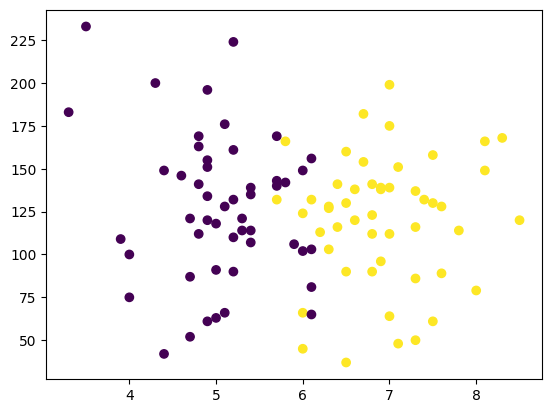

In [18]:
plt.scatter(df["cgpa"],df["iq"],c=df["placement"])
#cgpa in x-axis and iq in y=axis and color = placement.

# **1. Extract input and output columns**

In [19]:
x=df.iloc[:,0:2]# independent variable(iq,cgpa)
y=df.iloc[:,-1]# dependent variable(placement)

In [ ]:
y,x

(0     1
 1     0
 2     0
 3     1
 4     0
      ..
 95    0
 96    0
 97    1
 98    1
 99    1
 Name: placement, Length: 100, dtype: int64,
     cgpa     iq
 0    6.8  123.0
 1    5.9  106.0
 2    5.3  121.0
 3    7.4  132.0
 4    5.8  142.0
 ..   ...    ...
 95   4.3  200.0
 96   4.4   42.0
 97   6.7  182.0
 98   6.3  103.0
 99   6.2  113.0
 
 [100 rows x 2 columns])

# **3. Train Test Split (Cross Validation)**
Sometimes train the model process also in include in ML.

A package is a collection of modules, while a library is a collection of packages.

**scikit-learn/sklearn = library**

**Train Test Split after scaling**


sklearn.model_selection = package ,  train_test_split = class  

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)
#0.1 means 90% data will go to train and 10% data will go test randomaly.

# **2. Scale the values**
this process include first according to numering

sklearn.preprocessing = package ,  StandardScaler = class , scaler = object

In [22]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()# creating object of StandardScaler() function which has the power call every functions present in standardscaler

In [23]:
x_train=scaler.fit_transform(x_train) #scale data from -1 to 1

In [24]:
x_test=scaler.transform(x_test)# dont require fit cause it already reconize thepattern of data.

# **4. Evaluate the model / model selection**

sklearn.linear_model = package ,  LogisticRegression = class , clf = object

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
clf= LogisticRegression()

In [29]:
clf.fit(x_train,y_train) #model training

LogisticRegression()

In [30]:
y_pred=clf.predict(x_test) # x_test contain 10% data whose y_test value is hidden.

In [31]:
y_test

,placement
36,0
72,1
9,0
0,1
23,0
14,0
78,0
73,0
74,1
18,0


sklearn.metrics = package ,  accuracy_score = class

In [32]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy_score(y_test,y_pred) # checking accuracy . 90% data is accurate.

0.8

**Decision Bondary = ML model notices patterns in our model (visualize)**
**mlxtend = library**

mlxtend.plotting = package ,  plot_decision_regions = class

In [34]:
import mlxtend # Import the installed package

print(mlxtend.__version__) # Check the version if the package is installed correctly

0.23.4


In [35]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

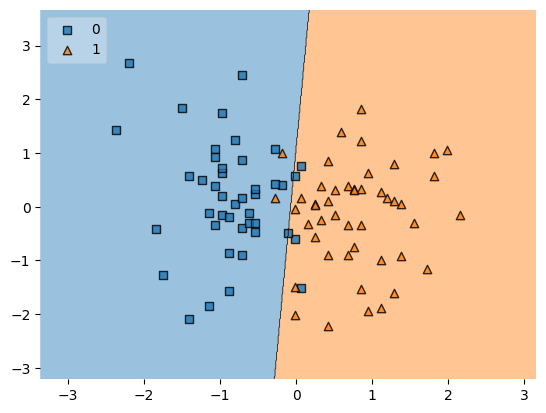

In [36]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

# **5. Deploy the model**

In [37]:
import pickle

In [38]:
pickle.dump(clf,open('model.pkl','wb'))